# Загальні налаштування
## Імпортування бібліотек і попередні налаштування

In [1]:
import os
import typing as ty
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
from pathlib import Path
from collections import Counter
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Optimizer
# import torchaudio
import soundfile as sf
from tqdm import tqdm
from transformers import AutoFeatureExtractor, HubertModel

/home/anton/.virtualenvs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
SEED = 42
LR = 3e-4
SKIP_OOM_BATCH = True
DEVICE_ID = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = torch.device(DEVICE_ID)
DEVICE_ID

'cuda'

## Службові функції

Функції, наведені нижче, призначені для допоміжних цілей: встановлення початкового значення генератора випадкових чисел і конверсії аргумента до булевого типу. 

In [5]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def _to_bool(v):
    if isinstance(v, bool):
        return v
    s = str(v).strip().lower()
    return s in {"1", "true", "t", "yes", "y"}

## Функції, необхідні для обробки послідовностей та безпосередньо аудіо-інформації

Дані функції призначені для нормалізації набору даних та обчислення метрик якості моделі, насамперед PER (Phoneme Error Rate). 

`_normalize_phoneme_string` використовується для часткової нормалізації (попередньої обробки) текстових представлень фонемних послідовностей.  
Вона приводить рядок до уніфікованого формату перед подальшим аналізом або порівнянням.

Функція `_levenshtein_distance` реалізує алгоритм відстані Левенштейна для двох послідовностей фонем.

Нехай:

- $A = (a_1, a_2, \ldots, a_n)$ — еталонна послідовність фонем,
- $B = (b_1, b_2, \ldots, b_m)$ — передбачена моделлю послідовність.

Алгоритм визначає мінімальну кількість операцій редагування, необхідних для перетворення $A$ у $B$.

Розглядаються три типи операцій:

- **Substitution (S)** — заміна фонеми,
- **Deletion (D)** — видалення фонеми,
- **Insertion (I)** — вставка фонеми.

Для обчислення використовується таблиця динамічного програмування

$$
dp \in \mathbb{R}^{(n+1) \times (m+1)},
$$

де кожна комірка містить кортеж

$$
(cost, S, D, I).
$$

Тут:

- $cost$ — загальна кількість операцій,
- $S$ — кількість замін,
- $D$ — кількість видалень,
- $I$ — кількість вставок.

Рекурентні співвідношення мають вигляд

$$
dp[i,j] =
\min
\begin{cases}
dp[i-1,j] + 1 & \text{(Deletion)} \\
dp[i,j-1] + 1 & \text{(Insertion)} \\
dp[i-1,j-1] + c & \text{(Substitution)}
\end{cases}
$$

де

$$
c =
\begin{cases}
0, & a_i = b_j \\
1, & a_i \neq b_j
\end{cases}
$$

Після заповнення таблиці в комірці

$$
dp[n,m]
$$

отримуємо кількість операцій

$$
(S, D, I).
$$

Функція `phoneme_error_rate` використовує отримані значення $S$, $D$ та $I$ для обчислення метрики PER.

PER визначається як

$$
PER = \frac{S + D + I}{N},
$$

де

- $S$ — кількість замін,
- $D$ — кількість видалень,
- $I$ — кількість вставок,
- $N$ — довжина еталонної фонемної послідовності.

Для уникнення ділення на нуль використовується

$$
N = \max(|ref|, 1).
$$

Ця метрика є стандартною для оцінювання систем автоматичного розпізнавання мовлення (ASR - automatic speech recognition) і відображає відносну кількість помилок у передбаченій послідовності фонем.

In [6]:
def _normalize_phoneme_string(value):
    text = str(value) if value is not None else ""
    text = text.strip()
    text = text.replace(",", " ")
    text = " ".join(text.split())
    
    return text


def _levenshtein_distance(seq_a, seq_b):
    n = len(seq_a)
    m = len(seq_b)

    dp = [[(0, 0, 0, 0) for _ in range(m + 1)] for _ in range(n + 1)]
    # (cost, S, D, I)

    for i in range(1, n + 1):
        cost, s, d, ins = dp[i - 1][0]
        dp[i][0] = (cost + 1, s, d + 1, ins)

    for j in range(1, m + 1):
        cost, s, d, ins = dp[0][j - 1]
        dp[0][j] = (cost + 1, s, d, ins + 1)

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            candidates = []

            if seq_a[i - 1] == seq_b[j - 1]:
                candidates.append(dp[i - 1][j - 1])
            else:
                cost, s, d, ins = dp[i - 1][j - 1]
                candidates.append((cost + 1, s + 1, d, ins))

            cost, s, d, ins = dp[i - 1][j]
            candidates.append((cost + 1, s, d + 1, ins))

            cost, s, d, ins = dp[i][j - 1]
            candidates.append((cost + 1, s, d, ins + 1))

            dp[i][j] = min(candidates, key=lambda x: x[0])

    _, S, D, I = dp[n][m]
    
    return S, D, I


def phoneme_error_rate(ref, hyp):
    S, D, I = _levenshtein_distance(ref, hyp)
    N = max(len(ref), 1)

    return (S+D+I)/N #, S, D, I

## Набір даних TIMIT і його обробка

Нижче визначено клас TIMIT_Dataset, що обробляє .wav і .phn-файли вихідного набору даних і приводить їх до форми, сумісної зі структурою даних Dataset фреймворка PyTorch, для подальшого навчання моделей. 

Функція `collect_phonemes` призначена для отримання множини фонем, що зустрічаються у наборі даних TIMIT, та побудови відповідних відображень між фонемами і числовими індексами. Вона створює два словники:
   - `phn2id` — відображення **фонема → числовий індекс**  
   - `id2phn` — відображення **індекс → фонема**

Ці словники використовуються для перетворення текстових позначень фонем у числові ідентифікатори, необхідні для навчання нейронної мережі.

Функція `collate_timit` виконує підготовку пакету даних (batch) для подачі у модель під час навчання або оцінювання.
Для використання функції втрат **CTC (Connectionist Temporal Classification)** створюються:
   - `targets` — об'єднаний вектор усіх фонем у пакети (батчі)
   - `target_lengths` — довжини кожної фонемної послідовності

Також повертаються:
   - `segments` — початкові сегменти фонем
   - `raw_input_lengths` — реальні довжини аудіосигналів

Ці дані подаються в модель під час навчання та/або оцінювання.

In [7]:
class TIMIT_Dataset(Dataset):
    def __init__(self, root: str, split: str = "TRAIN"):
        self.root = Path(root)
        self.split = split.upper()

        self.wav_paths = sorted(
            list((self.root / self.split).rglob("*.WAV")) +
            list((self.root / self.split).rglob("*.wav"))
        )

        if not self.wav_paths:
            raise RuntimeError(f"No WAV files found under {self.root / self.split}")

    def __len__(self):
        return len(self.wav_paths)

    def _find_phn_path(self, wav_path: Path) -> Path:
        base = wav_path.parent / wav_path.stem
        candidates = [
            base.with_suffix(".PHN"),
            base.with_suffix(".phn"),
        ]

        for p in candidates:
            if p.exists():
                return p

        raise FileNotFoundError(
            f"Could not find PHN file for WAV file: {wav_path}\n"
            f"Tried: {candidates}"
        )

    def __getitem__(self, idx):
        wav_path = self.wav_paths[idx]
        phn_path = self._find_phn_path(wav_path)

        waveform, sr = sf.read(str(wav_path))
        waveform = torch.tensor(waveform, dtype=torch.float32)
        
        # convert stereo → mono
        if waveform.ndim == 2:
            waveform = waveform.mean(dim=1)

        segments = []
        with open(phn_path, "r", encoding="utf-8") as f:
            for line in f:
                start_s, end_s, phn = line.strip().split()
                segments.append((int(start_s), int(end_s), phn))

        return {
            "waveform": waveform,
            "sample_rate": sr,
            "segments": segments,
            "wav_path": str(wav_path),
        }

In [8]:
def collect_phonemes(dataset):
    counter = Counter()
    for item in dataset:
        for _, _, phn in item["segments"]:
            counter[phn] += 1
    phones = sorted(counter.keys())
    phn2id = {p: i for i, p in enumerate(phones)}
    id2phn = {i: p for p, i in phn2id.items()}
    
    return phones, phn2id, id2phn


def collate_timit(batch):
    waveforms = [item["waveform"] for item in batch]
    segments_list = [item["segments"] for item in batch]

    lengths = torch.tensor([w.shape[0] for w in waveforms], dtype=torch.long)
    max_len = int(lengths.max().item())

    input_values = torch.zeros(len(batch), max_len, dtype=torch.float32)
    attention_mask = torch.zeros(len(batch), max_len, dtype=torch.long)

    for i, w in enumerate(waveforms):
        n = w.shape[0]
        input_values[i, :n] = w
        attention_mask[i, :n] = 1

    target_seqs = []
    for segments in segments_list:
        seq = [phn2id[phn] for _, _, phn in segments if phn in phn2id]
        target_seqs.append(torch.tensor(seq, dtype=torch.long))

    target_lengths = torch.tensor([len(seq) for seq in target_seqs], dtype=torch.long)

    if len(target_seqs) > 0:
        targets = torch.cat(target_seqs, dim=0)
    else:
        targets = torch.empty(0, dtype=torch.long)

    return {
        "input_values": input_values,
        "attention_mask": attention_mask,
        "targets": targets,
        "target_lengths": target_lengths,
        "segments": segments_list,
        "raw_input_lengths": lengths
    }

## Навчання моделі

Нижче визначено клас **PhonemeModel**, який є обгорткою над переднавченим SSL-бекбоном (self-supervised learning). Атрибут *hidden_layer_no* визначає номер прихованого шару SSL-бекбона, виходи якого використовуватимуться класифікаційною головою. У якості останньої виступає багатошаровий перцептрон (атрибут *mlp*) з функцією активації GELU (Gaussian Error Linear Unit):

$$
GELU(x) = x\Phi(x)
$$

Окремим важливим атрибутом є *blank_id*, що відповідає спеціальному токену-пропуску функції втрат CTC, де він використовується для узгодження послідовностей різної довжини. 

Для навчання та оцінювання моделі використовується алгоритм **Connectionist Temporal Classification (CTC)**, який дозволяє працювати з послідовностями різної довжини. Нижче наведено допоміжні функції, що забезпечують підготовку даних та декодування результатів.

`_split_ctc_targets` перетворює конкатенований одновимірний вектор CTC-таргетів у список окремих послідовностей.

Під час підготовки пакету (батчу) всі фонемні послідовності об’єднуються у вектор

$$
targets = (t_1, t_2, \ldots, t_K),
$$

де $K$ — сумарна довжина всіх послідовностей у батчі.

Масив `target_lengths` містить довжини окремих послідовностей:

$$
L = (L_1, L_2, \ldots, L_B),
$$

де $B$ — розмір батчу.

Функція відновлює початкову структуру

$$
targets \rightarrow [seq_1, seq_2, \ldots, seq_B].
$$

Функція `_ctc_greedy_decode` реалізує жадібне декодування (greedy decoding) для виходів CTC.

Нехай модель генерує тензор логітів

$$
logits \in \mathbb{R}^{B \times T \times C},
$$

де

- $B$ — розмір батчу,
- $T$ — кількість часових кроків,
- $C$ — кількість класів (фонем + blank).

На кожному кроці дискретного часу *t* вибирається найбільш імовірний клас

$$
y_t = \arg\max_c logits_{t,c}.
$$

Після цього застосовується стандартне правило CTC:

1. Видаляються повторювані токени.
2. Видаляється blank-токен.

У результаті формується передбачена послідовність фонем.

Функція `_process_batch` виконує основні операції підготовки батчу для навчання або оцінювання моделі.

Основні кроки:
    - Перенесення вхідних тензорів на обчислювальний пристрій (CPU або GPU).
    - Обнулення градієнтів оптимізатора (у режимі навчання).
    - Прямий прохід через модель

$$
    logits = f_\theta(x),
$$
    
де $f_\theta$ — нейронна мережа.
    
    - Обчислення логарифмів імовірностей

$$
\log p = \log \text{softmax}(logits).
$$
    - Обчислення реальної довжини послідовності після feature extractor SSL-моделі.

Це необхідно, оскільки CNN-частина SSL-бекбона зменшує часову роздільну здатність сигналу.

Функція `_update_history` відповідає за накопичення статистики навчання.

In [9]:
class PhonemeModel(nn.Module):
    def __init__(self, ssl_model: nn.Module, num_phonemes: int, mlp_size: int = 256, hidden_layer_no: int = -1, blank_id: int | None = None):
        super().__init__()
        self.ssl = ssl_model
        self.hidden_layer_no = hidden_layer_no
        hidden_size = ssl_model.config.hidden_size
        self.blank_id = num_phonemes if blank_id is None else blank_id
        
        self.mlp = nn.Sequential(
            nn.Linear(hidden_size, mlp_size),
            nn.GELU(),
            nn.Linear(mlp_size, num_phonemes+1)  # blank_id creates +1
        )

    def forward(self, x, attention_mask=None):
        out = self.ssl(x, attention_mask=attention_mask, output_hidden_states=True)

        features = out.hidden_states[self.hidden_layer_no]
        logits = self.mlp(features)
        return logits

In [10]:
def _split_ctc_targets(targets: torch.Tensor, target_lengths: torch.Tensor):
    """
    Convert concatenated 1D CTC targets into list[list[int]]
    """
    out = []
    start = 0
    for length in target_lengths.tolist():
        end = start + length
        out.append(targets[start:end].tolist())
        start = end
    return out
    

def _ctc_greedy_decode(logits: torch.Tensor, blank_id: int, input_lengths: torch.Tensor):
    pred_ids = torch.argmax(logits, dim=-1)  # [B, T]
    decoded = []

    batch_size = pred_ids.size(0)
    for b in range(batch_size):
        seq = pred_ids[b, :input_lengths[b]].tolist()

        out = []
        prev = None
        for token in seq:
            if token != prev:
                if token != blank_id:
                    out.append(token)
            prev = token

        decoded.append(out)

    return decoded
    

def _process_batch(batch: ty.Dict, model: PhonemeModel, opt: Optimizer, train_mode: bool = True, device: torch.device = DEVICE):
    input_values = batch["input_values"].to(device)         # [B, L]
    attention_mask = batch["attention_mask"].to(device)     # [B, L]
    targets = batch["targets"].to(device)                   # [sum(target_lengths)]
    target_lengths = batch["target_lengths"].to(device)     # [B]

    if train_mode:
        opt.zero_grad(set_to_none=True)

    logits = model(input_values, attention_mask=attention_mask)   # [B, T, C]
    log_probs = logits.log_softmax(dim=-1).transpose(0, 1)        # [T, B, C]
    
    batch_size, T, _ = logits.shape

    raw_input_lengths = batch["raw_input_lengths"].to(device)
    input_lengths = model.ssl._get_feat_extract_output_lengths(raw_input_lengths)

    return input_values, input_lengths, targets, target_lengths, logits, log_probs


def _update_history(history: ty.Dict[str, float], train_loss: float, train_per: float, test_loss: float, test_per: float) -> None:
    history["train_loss"].append(train_loss)
    history["train_per"].append(train_per)
    history["test_loss"].append(test_loss)
    history["test_per"].append(test_per)

Функція `shorten_phones` використовується для відображення фонем із початкового набору даних TIMIT у скорочений набір фонем. Вона є частиною нормалізації набору даних перед подачею до моделі для навчання.

Для кожної фонеми $p$ у послідовності виконується відображення

$$
p' = M(p),
$$

де $M$ — словник `SHORT_PHONES_MAP`.

Далі застосовуються правила:

- якщо $p'$ існує, фонема замінюється на нову,
- якщо $p' = None$, фонема пропускається,
- якщо відображення відсутнє, використовується початкове значення.

У результаті формується нова послідовність

$$
(p_1, p_2, \dots, p_n) \rightarrow (p'_1, p'_2, \dots, p'_k),
$$

де $k \le n$.

Отримана послідовність використовується для подальшого аналізу або обчислення метрики PER у скороченому фонемному просторі.

In [11]:
SHORT_PHONES_MAP = {
    "aa": "aa",
    "ae": "ae",
    "ah": "ah",
    "ao": "aa",
    "aw": "aw",
    "ax": "ah",
    "ax-h": "ah",
    "axr": "er",
    "ay": "ay",
    "b": "b",
    "bcl": "sil",
    "ch": "ch",
    "d": "d",
    "dcl": "sil",
    "dh": "dh",
    "dx": "dx",
    "eh": "eh",
    "el": "l",
    "em": "m",
    "en": "n",
    "eng": "ng",
    "epi": "sil",
    "er": "er",
    "ey": "ey",
    "f": "f",
    "g": "g",
    "gcl": "sil",
    "h#": "sil",
    "hh": "hh",
    "hv": "hh",
    "ih": "ih",
    "ix": "ih",
    "iy": "iy",
    "jh": "jh",
    "k": "k",
    "kcl": "sil",
    "l": "l",
    "m": "m",
    "n": "n",
    "ng": "ng",
    "nx": "n",
    "ow": "ow",
    "oy": "oy",
    "p": "p",
    "pau": "sil",
    "pcl": "sil",
    "q": None,
    "r": "r",
    "s": "s",
    "sh": "sh",
    "t": "t",
    "tcl": "sil",
    "th": "th",
    "uh": "uh",
    "uw": "uw",
    "ux": "uw",
    "v": "v",
    "w": "w",
    "y": "y",
    "z": "z",
    "zh": "sh",
}

In [12]:
def shorten_phones(seq, short_map=SHORT_PHONES_MAP):
    out = []
    for phn in seq:
        mapped = short_map.get(phn, phn)
        if mapped is None:
            continue
        out.append(mapped)
    return out

Функції `evaluate` і `train` використовуються для оцінювання та навчання моделі відповідно. 

In [13]:
@torch.no_grad()
def evaluate(model: PhonemeModel, dl: DataLoader, loss_fn: nn.Module, device: torch.device = DEVICE):
    model.eval()

    total_loss = .0
    total_per = .0
    total_items = 0
    for batch in dl:
        input_values, input_lengths, targets, target_lengths, logits, log_probs = _process_batch(batch, model, opt, train_mode=False)
    
        loss = loss_fn(
            log_probs,
            targets,
            input_lengths,
            target_lengths
        )
    
        total_loss += loss.item()
        pred_seqs = _ctc_greedy_decode(
                logits=logits,
                blank_id=model.blank_id,
                input_lengths=input_lengths
            )
        ref_seqs = _split_ctc_targets(targets.detach().cpu(), target_lengths.detach().cpu())
        for ref, hyp in zip(ref_seqs, pred_seqs):
            ref_full = [id2phn[x] for x in ref]
            hyp_full = [id2phn[x] for x in hyp]
        
            ref_short = shorten_phones(ref_full)
            hyp_short = shorten_phones(hyp_full)
            
            per = phoneme_error_rate(ref_short, hyp_short)
            total_per += per
            total_items += 1

    mean_loss = total_loss / max(len(dl), 1)
    mean_per = total_per / max(total_items, 1)
    
    return mean_loss, mean_per

In [14]:
def train(model: PhonemeModel, train_dl: DataLoader, test_dl: DataLoader, opt: Optimizer, num_epochs: int, device: torch.device = DEVICE):
    model.to(device)
    ctc_loss_fn = nn.CTCLoss(blank=model.blank_id, zero_infinity=True, reduction="sum")
    
    history = {
        "train_loss": [],
        "train_per": [],
        "test_loss": [],
        "test_per": [],
    }
    best_per = np.inf
    best_state = None
    
    for epoch_no in tqdm(range(num_epochs)):
        total_loss = .0
        total_per = .0
        total_items = 0

        model.train()
        model.ssl.eval()
        
        for batch in train_dl:
            try:
                input_values, input_lengths, targets, target_lengths, logits, log_probs = _process_batch(batch, model, opt)

                loss = ctc_loss_fn(
                    log_probs,
                    targets,
                    input_lengths,
                    target_lengths
                )

                loss.backward()
                opt.step()

                total_loss += loss.item()
                
                with torch.no_grad():
                    pred_seqs = _ctc_greedy_decode(
                        logits=logits,
                        blank_id=model.blank_id,
                        input_lengths=input_lengths
                    )
                    ref_seqs = _split_ctc_targets(
                        targets.detach().cpu(),
                        target_lengths.detach().cpu()
                    )

                    for ref, hyp in zip(ref_seqs, pred_seqs):
                        ref_full = [id2phn[x] for x in ref]
                        hyp_full = [id2phn[x] for x in hyp]
                    
                        ref_short = shorten_phones(ref_full)
                        hyp_short = shorten_phones(hyp_full)
                        
                        per = phoneme_error_rate(ref_short, hyp_short)
                        total_per += per
                        total_items += 1
                
            except RuntimeError as e:
                if "out of memory" in str(e).lower():
                    print(f"[WARNING] OOM error: skipping epoch #{epoch_no}")
                    opt.zero_grad(set_to_none=True)
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()
                    continue
            except Exception as e:
                raise e
            
        train_loss = total_loss / max(len(train_dl), 1)
        train_per = total_per / max(total_items, 1)

        test_loss, test_per = evaluate(
            model=model,
            dl=test_dl,
            loss_fn=ctc_loss_fn,
            device=device
        )

        _update_history(history, train_loss, train_per, test_loss, test_per)
        if test_per < best_per:
            best_per = test_per
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        print(
            f"epoch={epoch_no:03d} "
            f"train_loss={train_loss:.4f} "
            f"train_per={train_per:.4f} "
            f"test_loss={test_loss:.4f} "
            f"test_per={test_per:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_per

## Підготовка структур даних

In [15]:
train_ds = TIMIT_Dataset("timit/data", "TRAIN")
test_ds = TIMIT_Dataset("timit/data", "TEST")

In [16]:
phones, phn2id, id2phn = collect_phonemes(train_ds)

In [15]:
len(phones), phones

(61,
 ['aa',
  'ae',
  'ah',
  'ao',
  'aw',
  'ax',
  'ax-h',
  'axr',
  'ay',
  'b',
  'bcl',
  'ch',
  'd',
  'dcl',
  'dh',
  'dx',
  'eh',
  'el',
  'em',
  'en',
  'eng',
  'epi',
  'er',
  'ey',
  'f',
  'g',
  'gcl',
  'h#',
  'hh',
  'hv',
  'ih',
  'ix',
  'iy',
  'jh',
  'k',
  'kcl',
  'l',
  'm',
  'n',
  'ng',
  'nx',
  'ow',
  'oy',
  'p',
  'pau',
  'pcl',
  'q',
  'r',
  's',
  'sh',
  't',
  'tcl',
  'th',
  'uh',
  'uw',
  'ux',
  'v',
  'w',
  'y',
  'z',
  'zh'])

In [17]:
short_phones = shorten_phones(phones)
len(short_phones), short_phones

(60,
 ['aa',
  'ae',
  'ah',
  'aa',
  'aw',
  'ah',
  'ah',
  'er',
  'ay',
  'b',
  'sil',
  'ch',
  'd',
  'sil',
  'dh',
  'dx',
  'eh',
  'l',
  'm',
  'n',
  'ng',
  'sil',
  'er',
  'ey',
  'f',
  'g',
  'sil',
  'sil',
  'hh',
  'hh',
  'ih',
  'ih',
  'iy',
  'jh',
  'k',
  'sil',
  'l',
  'm',
  'n',
  'ng',
  'n',
  'ow',
  'oy',
  'p',
  'sil',
  'sil',
  'r',
  's',
  'sh',
  't',
  'sil',
  'th',
  'uh',
  'uw',
  'uw',
  'v',
  'w',
  'y',
  'z',
  'sh'])

In [17]:
train_dl = DataLoader(train_ds, batch_size=12, shuffle=True, collate_fn=collate_timit)
test_dl = DataLoader(test_ds, batch_size=12, shuffle=False, collate_fn=collate_timit)

## Навчання й оцінювання моделей

Тут і нижче навчання моделей відбувається за допомогою алгоритму оптимізації ADAMW. 

У якості SSL-бекбонів для порівняння було обрано моделі HuBERT, Wav2vec2 та WavLM. Для кожної з них було створено по дві реалізації: з використанням виходів останнього прихованого рівня (індекс -1) і одного з початкових рівнів (2). Дане розділення має на меті порівнняня якості моделі за метрикою PER за припущення, що початкові приховані рівні відповідають низькорівневим ознакам (спектральним характеристикам, енергії сигналу тощо), а останній, відповідно, високорівневим (особа спікера, семантичний контекст, довгострокові закономірності тощо).

З огляду на значну ресурсозатратність процесу навчання та обмеження локальної машини, на якій воно відбуватиметься, воно буде обмежено 10-ма епохами.

### Модель HuBERT як SSL-бекбон: останній прихований шар

In [20]:
from transformers import HubertForCTC

In [21]:
torch.cuda.empty_cache()

In [26]:
ssl_model = HubertForCTC.from_pretrained("facebook/hubert-base-ls960")

model = PhonemeModel(ssl_model, len(short_phones), mlp_size=128, hidden_layer_no=-1).to(DEVICE)

for p in model.ssl.parameters():
    p.requires_grad = False

opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 211/211 [00:00<00:00, 36202.17it/s]
HubertForCTC LOAD REPORT from: facebook/hubert-base-ls960
Key            | Status  | 
---------------+---------+-
lm_head.bias   | MISSING | 
lm_head.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [27]:
_, history, per = train(model, train_dl, test_dl, opt, 10)

 10%|█████████████████                                                                                                                                                          | 1/10 [08:40<1:18:07, 520.89s/it]

epoch=000 train_loss=1314.1356 train_per=0.6971 test_loss=429.1521 test_per=0.2837


 20%|██████████████████████████████████▏                                                                                                                                        | 2/10 [17:29<1:10:05, 525.67s/it]

epoch=001 train_loss=357.3647 train_per=0.2129 test_loss=316.8605 test_per=0.1845


 30%|███████████████████████████████████████████████████▎                                                                                                                       | 3/10 [26:23<1:01:45, 529.40s/it]

...

epoch=007 train_loss=214.7491 train_per=0.1163 test_loss=227.2888 test_per=0.1196


 90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉                 | 9/10 [1:19:37<08:51, 531.16s/it]

epoch=008 train_loss=206.5948 train_per=0.1114 test_loss=223.0893 test_per=0.1199


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [1:28:27<00:00, 530.79s/it]

epoch=009 train_loss=199.6266 train_per=0.1076 test_loss=218.4446 test_per=0.1199


In [28]:
history

{'train_loss': [1314.135608029056,
  357.3647286353173,
  296.28017958603897,
  267.8624310778333,
  249.1270017153257,
  235.02009134664164,
  223.92812295888925,
  214.74914273348722,
  206.59483629697328,
  199.62655952750862],
 'train_per': [0.6971460818885825,
  0.2129294697015639,
  0.16739065160605396,
  0.14798871664469077,
  0.13595448327004886,
  0.12757661521116614,
  0.12105668834724873,
  0.11627707201930332,
  0.11139515066712449,
  0.10762970136944053],
 'test_loss': [429.1520683288574,
  316.86045069013323,
  283.2868931361607,
  264.4639863695417,
  251.42587814331054,
  242.2751759665353,
  233.77669715881348,
  227.28878498077393,
  223.0893180847168,
  218.44457394736153],
 'test_per': [0.28367876704291595,
  0.18450397240956942,
  0.15802974567698458,
  0.1461687954114132,
  0.13434115684356293,
  0.12905459327069785,
  0.12716831819259505,
  0.11962178934974665,
  0.11994739217711407,
  0.11993320098350516]}

In [29]:
per

0.11962178934974665

Крива навчання за критерієм CTC є крутою, демонструючи швидку збіжність. Остаточне значення PER на тестовій вибірці складає ~0.12. 

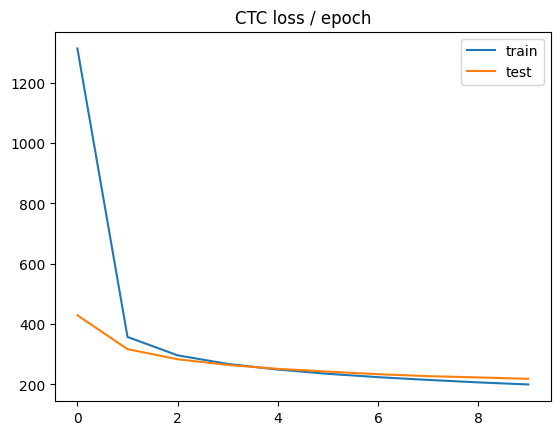

In [36]:
plt.plot(history["train_loss"], label="train")
plt.plot(history["test_loss"], label="test")
plt.title("CTC loss / epoch")
plt.legend()
plt.show()

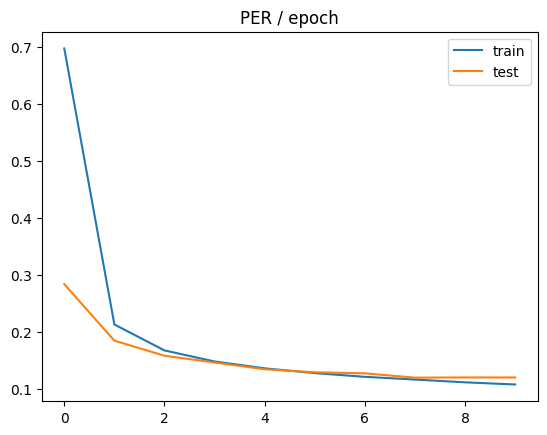

In [34]:
plt.plot(history["train_per"], label="train")
plt.plot(history["test_per"], label="test")
plt.title("PER / epoch")
plt.legend()
plt.show()

In [30]:
torch.save(model.state_dict(), "hubert_ctc.pth")

## HuBERT - ранній прихований шар

Модель HuBERT із використанням прихованих шарів низького рівня. 

In [22]:
ssl_model = HubertForCTC.from_pretrained("facebook/hubert-base-ls960")

model = PhonemeModel(ssl_model, len(short_phones), mlp_size=128, hidden_layer_no=2).to(DEVICE)

for p in model.ssl.parameters():  # Disabling gradient for SSL
    p.requires_grad = False

opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 211/211 [00:00<00:00, 35060.54it/s]
HubertForCTC LOAD REPORT from: facebook/hubert-base-ls960
Key            | Status  | 
---------------+---------+-
lm_head.weight | MISSING | 
lm_head.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [23]:
_, history, per = train(model, train_dl, test_dl, opt, 10)

 10%|█████████████████                                                                                                                                                          | 1/10 [08:29<1:16:27, 509.69s/it]

epoch=000 train_loss=1714.4830 train_per=0.8919 test_loss=867.7750 test_per=0.6149


 20%|██████████████████████████████████▏                                                                                                                                        | 2/10 [17:06<1:08:28, 513.62s/it]

epoch=001 train_loss=644.1440 train_per=0.4498 test_loss=544.7221 test_per=0.3792


 30%|███████████████████████████████████████████████████▎                                                                                                                       | 3/10 [25:47<1:00:19, 517.04s/it]

...

epoch=007 train_loss=379.8587 train_per=0.2354 test_loss=402.2244 test_per=0.2540


 90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉                 | 9/10 [1:18:12<08:43, 523.49s/it]

epoch=008 train_loss=368.2099 train_per=0.2256 test_loss=394.2156 test_per=0.2477


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [1:26:56<00:00, 521.67s/it]

epoch=009 train_loss=358.1767 train_per=0.2179 test_loss=388.2788 test_per=0.2420


In [24]:
history

{'train_loss': [1714.4830301656352,
  644.143964732777,
  504.3176984910841,
  458.3603010301466,
  430.4232262945794,
  409.9293335753602,
  393.6670189002892,
  379.85865308092787,
  368.20991680591135,
  358.176667151513],
 'train_per': [0.8918703093016707,
  0.449755524849763,
  0.33478601623215654,
  0.29916018198363165,
  0.2768930238911964,
  0.2599863620684676,
  0.2464756569918212,
  0.2353564172078092,
  0.2255949872651666,
  0.21794459892085496],
 'test_loss': [867.7750239780971,
  544.7221161978586,
  486.1991692679269,
  456.6920981270926,
  437.695762525286,
  423.12950504847936,
  411.19046478271486,
  402.2244437081473,
  394.2155697413853,
  388.2787551879883],
 'test_per': [0.6149200028334852,
  0.3792057725473369,
  0.3276632374105814,
  0.3057830820444944,
  0.28070989408518016,
  0.27237308095004165,
  0.2633813158877018,
  0.25395624193821975,
  0.24765267357844675,
  0.2419606939067211]}

In [25]:
per

0.2419606939067211

Крива навчання також є крутою, що може пояснюватися градієнтною природою алгоритму оптимізації ADAMW. Водночас, кінцеве значення PER на тестовії вибірці є більш, ніж удвічі вищим за попередній сценарій (використання прихованого шару останнього рівня). 

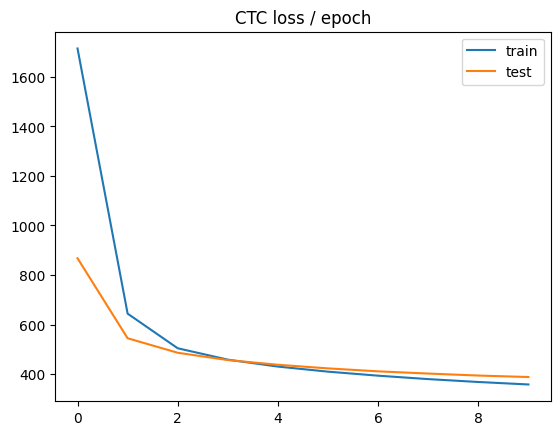

In [27]:
plt.plot(history["train_loss"], label="train")
plt.plot(history["test_loss"], label="test")
plt.title("CTC loss / epoch")
plt.legend()
plt.show()

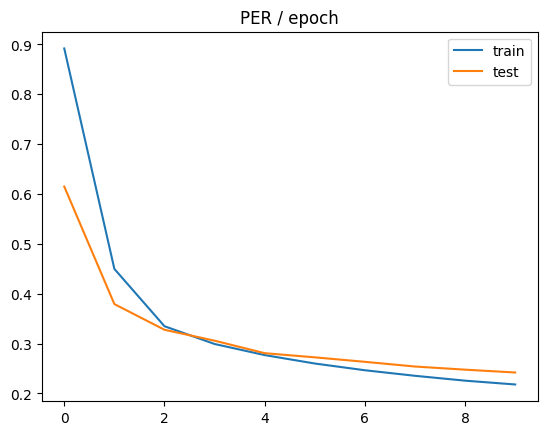

In [28]:
plt.plot(history["train_per"], label="train")
plt.plot(history["test_per"], label="test")
plt.title("PER / epoch")
plt.legend()
plt.show()

In [26]:
torch.save(model.state_dict(), "hubert_lowlevel.pth")

## HuBERT Large - останній прихований шар

Спроба завантаження переднавченої моделі HuBERT Large для використання в якості SSL-бекбону.

In [30]:
ssl_model = HubertForCTC.from_pretrained("facebook/hubert-large-ll60k")

model = PhonemeModel(ssl_model, len(short_phones), mlp_size=128, hidden_layer_no=-1).to(DEVICE)

for p in model.ssl.parameters():  # Disabling gradient for SSL
    p.requires_grad = False

opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 422/422 [00:00<00:00, 27729.41it/s]
HubertForCTC LOAD REPORT from: facebook/hubert-large-ll60k
Key            | Status  | 
---------------+---------+-
lm_head.weight | MISSING | 
lm_head.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [31]:
_, history, per = train(model, train_dl, test_dl, opt, 10)

  0%|                                                                                                                                                                                      | 0/10 [00:00<?, ?it/s]

[WARNING] OOM error: skipping epoch #0
[WARNING] OOM error: skipping epoch #0


  0%|                                                                                                                                                                                      | 0/10 [19:29<?, ?it/s]


KeyboardInterrupt: 

Навчання було зупинено вручну, оскільки для моделі HuBERT Large не вистачає обчислювальних ресурсів машини.

## Wav2vec2

На відміну від HuBERT, яка розв'язує задачу класифікації, wav2vec2 є більш ранньою моделлю, що прогнозує відповідність векторів ознак маскованим часовим проміжкам даних. Для навчання використовуються негативні підвибірки даних (contrastive learning). Очікується, що її використання в якості переднавченого SSL-бекбона створить менш якісну модель за метрикою PER, ніж HuBERT. 

In [20]:
from transformers import Wav2Vec2Model

In [21]:
ssl_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")

model = PhonemeModel(ssl_model, len(short_phones), mlp_size=128, hidden_layer_no=-1).to(DEVICE)

for p in model.ssl.parameters():  # Disabling gradient for SSL
    p.requires_grad = False

opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 211/211 [00:00<00:00, 28800.10it/s]
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
_, history, per = train(model, train_dl, test_dl, opt, 10)

 10%|█████████████████                                                                                                                                                          | 1/10 [08:32<1:16:52, 512.47s/it]

epoch=000 train_loss=1610.0613 train_per=0.8463 test_loss=1158.3190 test_per=0.6722


 20%|██████████████████████████████████▏                                                                                                                                        | 2/10 [17:11<1:08:52, 516.56s/it]

epoch=001 train_loss=993.6336 train_per=0.5957 test_loss=884.7602 test_per=0.5629


 30%|███████████████████████████████████████████████████▎                                                                                                                       | 3/10 [25:54<1:00:33, 519.10s/it]

...

epoch=007 train_loss=544.1481 train_per=0.3862 test_loss=540.5828 test_per=0.3937


 90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉                 | 9/10 [1:18:32<08:46, 526.45s/it]

epoch=008 train_loss=517.6216 train_per=0.3653 test_loss=519.0282 test_per=0.3590


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [1:27:21<00:00, 524.14s/it]

epoch=009 train_loss=495.5053 train_per=0.3480 test_loss=499.0655 test_per=0.3525


In [23]:
history

{'train_loss': [1610.0612743030895,
  993.6336298954951,
  816.2222315404322,
  724.2053752948711,
  660.8475530450994,
  613.1993433172053,
  576.0898227840275,
  544.1481183336927,
  517.6215773545302,
  495.50532884473927],
 'train_per': [0.8463374643362727,
  0.5956635949677473,
  0.5250920164889222,
  0.4857121257197764,
  0.4565271471398373,
  0.4301606372032336,
  0.4082615036068849,
  0.3862325452687484,
  0.3652791270717774,
  0.3480366661969462],
 'test_loss': [1158.319039263044,
  884.7602421351842,
  767.0411579677037,
  695.412134878976,
  641.389896937779,
  601.8539467947824,
  567.6983688354492,
  540.5827564784458,
  519.0282303946359,
  499.06552963256837],
 'test_per': [0.6721670960998656,
  0.5628683421935848,
  0.5160807600172471,
  0.4919963228525015,
  0.452393352569372,
  0.43485739451718897,
  0.4107218684356702,
  0.39367277232470627,
  0.35900900374904904,
  0.35252402438388675]}

In [24]:
per

0.35252402438388675

Як і очікувалося, значення PER для тестової вибірки складає близько 0.35 на противагу 0.12 для HuBERT. Крива навчання за CTC також є більш пологою. 

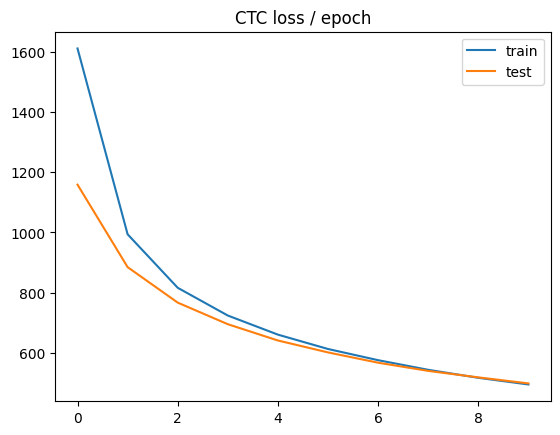

In [25]:
plt.plot(history["train_loss"], label="train")
plt.plot(history["test_loss"], label="test")
plt.title("CTC loss / epoch")
plt.legend()
plt.show()

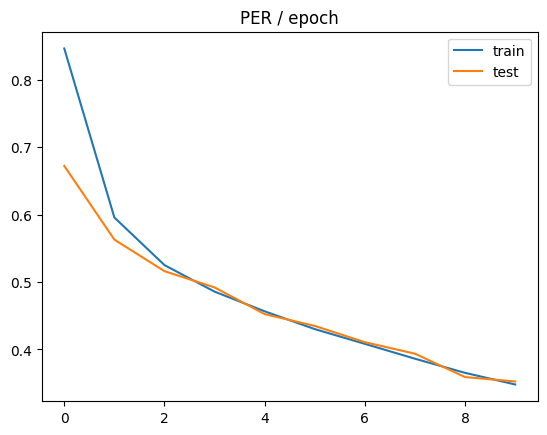

In [26]:
plt.plot(history["train_per"], label="train")
plt.plot(history["test_per"], label="test")
plt.title("PER / epoch")
plt.legend()
plt.show()

In [27]:
torch.save(model.state_dict(), "wav2vec2.pth")

## Wav2vec2 - ранній прихований шар

Модель wav2vec2 з прихованим шаром низького рівня.

In [28]:
ssl_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")

model = PhonemeModel(ssl_model, len(phones), mlp_size=128, hidden_layer_no=2).to(DEVICE)

for p in model.ssl.parameters():  # Disabling gradient for SSL
    p.requires_grad = False

opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 211/211 [00:00<00:00, 37783.30it/s]
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [29]:
_, history, per = train(model, train_dl, test_dl, opt, 10)

 10%|█████████████████                                                                                                                                                          | 1/10 [08:40<1:18:04, 520.46s/it]

epoch=000 train_loss=1040.4197 train_per=0.5788 test_loss=452.4739 test_per=0.3116


 20%|██████████████████████████████████▏                                                                                                                                        | 2/10 [17:29<1:10:06, 525.77s/it]

epoch=001 train_loss=402.4686 train_per=0.2574 test_loss=382.9931 test_per=0.2420


 30%|███████████████████████████████████████████████████▎                                                                                                                       | 3/10 [26:19<1:01:33, 527.67s/it]

...

epoch=007 train_loss=255.0697 train_per=0.1499 test_loss=341.9675 test_per=0.1964


 90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉                 | 9/10 [1:19:27<08:50, 530.95s/it]

epoch=008 train_loss=244.3780 train_per=0.1435 test_loss=344.8795 test_per=0.1974


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [1:28:19<00:00, 529.97s/it]

epoch=009 train_loss=235.1536 train_per=0.1384 test_loss=349.9235 test_per=0.1959


In [30]:
history

{'train_loss': [1040.4197474888392,
  402.4686253931615,
  350.7260538670924,
  320.9915525163923,
  298.50415027172534,
  281.67517981591163,
  267.3758926193436,
  255.0697393442129,
  244.37803842123452,
  235.1536424314821],
 'train_per': [0.5788214822144417,
  0.25744219367914706,
  0.21571297636416878,
  0.19311180495539243,
  0.17703742755824897,
  0.16639442647380848,
  0.15759688997722743,
  0.14994857466236755,
  0.14345560060066695,
  0.13842157717758466],
 'test_loss': [452.4738676888602,
  382.99309392656596,
  359.8348751613072,
  346.5300430842808,
  339.5973766871861,
  338.84103611537387,
  338.37643236432757,
  341.96753316606794,
  344.87948880876814,
  349.92354115077427],
 'test_per': [0.3115882414079583,
  0.24195318677724645,
  0.2193915542367542,
  0.20669978302537134,
  0.20015122125085424,
  0.19349227787088832,
  0.19587343027767193,
  0.19635485710697623,
  0.19741998917402223,
  0.19585696022263105]}

In [31]:
per

0.19349227787088832

Метрика PER на тестовій вибірці в даному випадку є значно кращою, ніж для попередньої реалізації (останній прихований рівень). Це може пояснюватися тим, що нижчі приховані шари wav2vec2 є ближчими до класів фонем, ніж шари вищих рівнів. Ймовірно також, що contrastive learning продукує більше лінійно сепарабельних ознак на нижчих рівнях, що є легшими для розв'язання задачі класифікації MLP-головою. 

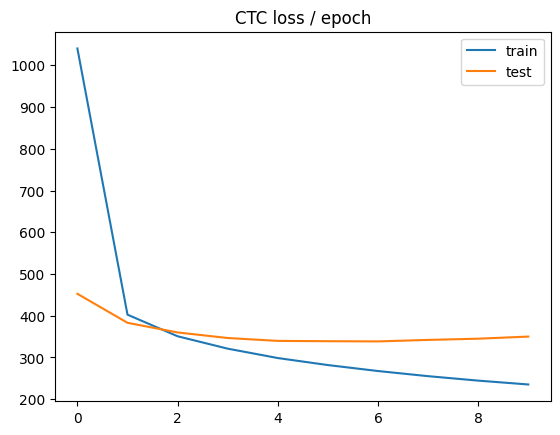

In [32]:
plt.plot(history["train_loss"], label="train")
plt.plot(history["test_loss"], label="test")
plt.title("CTC loss / epoch")
plt.legend()
plt.show()

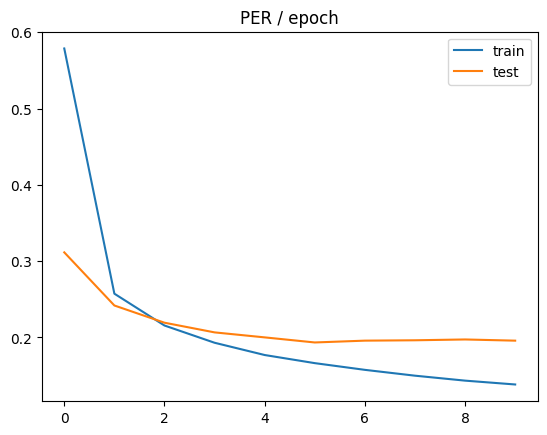

In [33]:
plt.plot(history["train_per"], label="train")
plt.plot(history["test_per"], label="test")
plt.title("PER / epoch")
plt.legend()
plt.show()

In [34]:
torch.save(model.state_dict(), "wav2vec2_lowlevel.pth")

## WavLM

Модель WavLM [було запропоновано](https://arxiv.org/pdf/2110.13900) колективом авторів (Chen <i>et al.</i>) у 2022 році. 

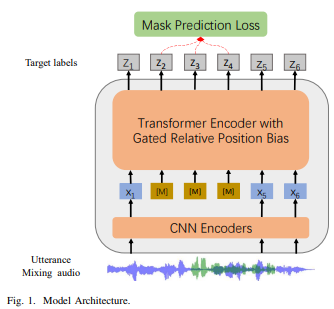

Серед головних її нововведень був видозмінений механізм само-уваги з порогами:

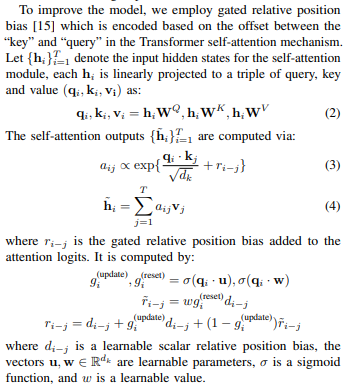. 

Цей механізм дозволяє обмежити ступінь впливу сусідніх токенів. Дане рішення є корисним у випадках змішування різних вимов і артикуляцій (utterance mixing) різних спікерів, коли тематика висловлювань є важливішою за позиції фонем. 

In [18]:
from transformers import WavLMModel

In [19]:
ssl_model = WavLMModel.from_pretrained("microsoft/wavlm-base-plus")

model = PhonemeModel(ssl_model, len(short_phones), mlp_size=128, hidden_layer_no=-1).to(DEVICE)

for p in model.ssl.parameters():
    p.requires_grad = False

opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 248/248 [00:00<00:00, 39759.48it/s]


In [20]:
_, history, per = train(model, train_dl, test_dl, opt, 10)

  0%|                                                                                                                                                                                      | 0/10 [00:00<?, ?it/s]/home/anton/.virtualenvs/.venv/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
 10%|█████████████████                                                                                                                                                          | 1/10 [13:47<2:04:05, 827.27s/it]

epoch=000 train_loss=1899.9980 train_per=0.9409 test_loss=997.4084 test_per=0.7009


 20%|██████████████████████████████████▏                                                                                                                                        | 2/10 [27:50<1:51:34, 836.80s/it]

epoch=001 train_loss=459.9720 train_per=0.2859 test_loss=316.0449 test_per=0.1835


 30%|███████████████████████████████████████████████████▎                                                                                                                       | 3/10 [41:54<1:38:00, 840.04s/it]

...

epoch=007 train_loss=213.4673 train_per=0.1126 test_loss=218.2357 test_per=0.1143


 90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉                 | 9/10 [2:06:31<14:06, 846.20s/it]

epoch=008 train_loss=206.6020 train_per=0.1088 test_loss=213.2666 test_per=0.1109


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [2:20:39<00:00, 843.98s/it]

epoch=009 train_loss=200.5773 train_per=0.1060 test_loss=209.4829 test_per=0.1080


In [21]:
history

{'train_loss': [1899.998014375761,
  459.9719685740285,
  292.54763585870916,
  261.6643655950373,
  244.099712203385,
  231.5659682633041,
  221.64273467621246,
  213.4673236202884,
  206.60201679576528,
  200.57731492674196],
 'train_per': [0.9408549323210957,
  0.28593788332163295,
  0.15957335047489382,
  0.1391327491438198,
  0.12854321414201456,
  0.12239645094820509,
  0.11672940914014261,
  0.11264546849687457,
  0.10881209234463285,
  0.10603329488454996],
 'test_loss': [997.4083526611328,
  316.04488247462683,
  272.37187222072055,
  252.0935221535819,
  239.7459300994873,
  230.1694046292986,
  223.11740014212472,
  218.23571962629046,
  213.26657030923025,
  209.48286124638147],
 'test_per': [0.7008960608566888,
  0.1835440860078087,
  0.14581675045730824,
  0.13267050043414214,
  0.12849293816186302,
  0.12324466181789635,
  0.11912779767828591,
  0.11434993421590825,
  0.11087322119053479,
  0.10802245602177556]}

Очікувано, значення PER ~0.1 для тестової вибірки є найнижчою серед усіх моделей, які було досі розглянуто. Крива навчання за CTC демонструє найшвидшу збіжність функції втрат. 

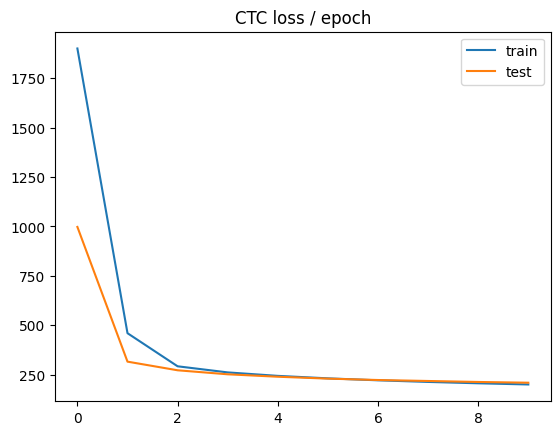

In [22]:
plt.plot(history["train_loss"], label="train")
plt.plot(history["test_loss"], label="test")
plt.title("CTC loss / epoch")
plt.legend()
plt.show()

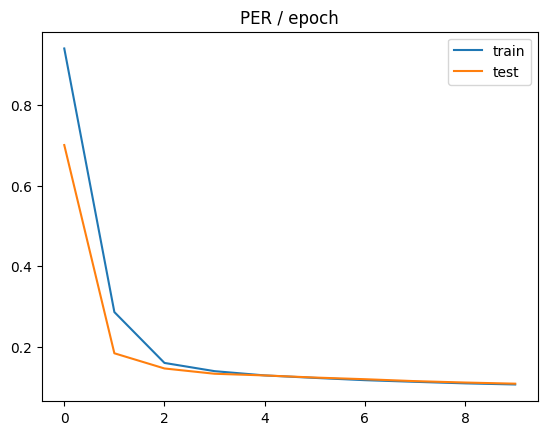

In [23]:
plt.plot(history["train_per"], label="train")
plt.plot(history["test_per"], label="test")
plt.title("PER / epoch")
plt.legend()
plt.show()

In [24]:
torch.save(model.state_dict(), "wavlm.pth")

## WavLM - ранній прихований шар

In [25]:
ssl_model = WavLMModel.from_pretrained("microsoft/wavlm-base-plus")

model = PhonemeModel(ssl_model, len(short_phones), mlp_size=128, hidden_layer_no=2).to(DEVICE)

for p in model.ssl.parameters():
    p.requires_grad = False

opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 248/248 [00:00<00:00, 38010.21it/s]


In [26]:
_, history, per = train(model, train_dl, test_dl, opt, 10)

 10%|█████████████████                                                                                                                                                          | 1/10 [13:55<2:05:15, 835.08s/it]

epoch=000 train_loss=1677.2629 train_per=0.9020 test_loss=877.4831 test_per=0.6341


 20%|██████████████████████████████████▏                                                                                                                                        | 2/10 [27:57<1:51:53, 839.22s/it]

epoch=001 train_loss=654.2374 train_per=0.4586 test_loss=550.9662 test_per=0.3776


 30%|███████████████████████████████████████████████████▎                                                                                                                       | 3/10 [42:03<1:38:16, 842.31s/it]

...

epoch=007 train_loss=386.0027 train_per=0.2409 test_loss=403.5732 test_per=0.2528


 90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉                 | 9/10 [2:06:40<14:05, 845.96s/it]

epoch=008 train_loss=374.8745 train_per=0.2318 test_loss=396.2199 test_per=0.2501


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [2:20:46<00:00, 844.69s/it]

epoch=009 train_loss=365.2209 train_per=0.2244 test_loss=390.8364 test_per=0.2388


In [27]:
history

{'train_loss': [1677.2629237583706,
  654.2374042065113,
  512.7184202119902,
  465.58389523989194,
  436.8406670508447,
  415.8201005811815,
  399.29096818403764,
  386.00273021351205,
  374.8744762866528,
  365.22092255431335],
 'train_per': [0.9019571678576611,
  0.45860765389055397,
  0.3444452491053652,
  0.30648012267166463,
  0.28213452116479365,
  0.2643062276527938,
  0.25060290042672656,
  0.2409367454044669,
  0.23178650992085745,
  0.2243532910772757],
 'test_loss': [877.4831218174526,
  550.9661949157714,
  490.02817371913363,
  458.8187130519322,
  438.18385587419783,
  423.8097348894392,
  412.2431792122977,
  403.573225075858,
  396.2199399675642,
  390.8363969530378],
 'test_per': [0.6341056567464316,
  0.37755918790912774,
  0.3179430180287787,
  0.30163270375596296,
  0.2863697727955493,
  0.27817938271827614,
  0.25932882348843145,
  0.2528111637101637,
  0.250108979638302,
  0.23877373983191288]}

In [28]:
per

0.23877373983191288

Значення PER для SSL-бекбону WavLM з використанням низькорівневого прихованого шару є гіршою та складає ~0.24.

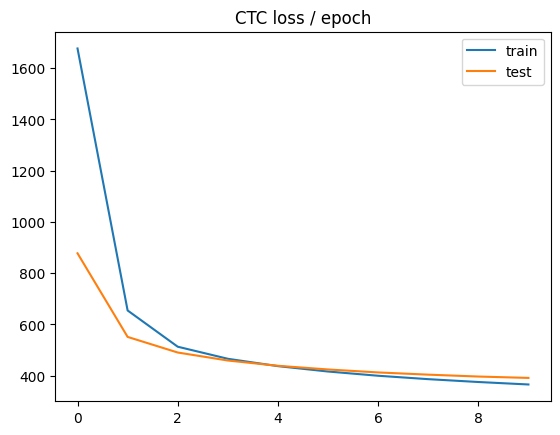

In [29]:
plt.plot(history["train_loss"], label="train")
plt.plot(history["test_loss"], label="test")
plt.title("CTC loss / epoch")
plt.legend()
plt.show()

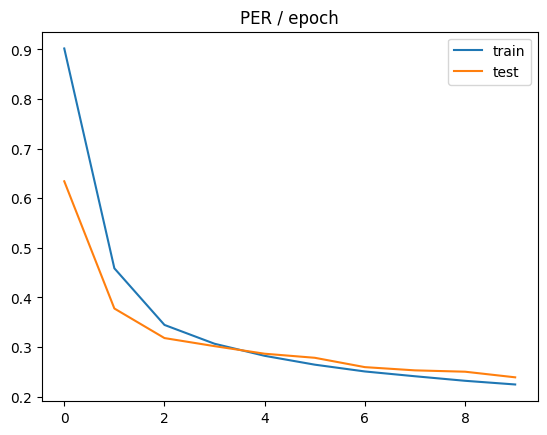

In [30]:
plt.plot(history["train_per"], label="train")
plt.plot(history["test_per"], label="test")
plt.title("PER / epoch")
plt.legend()
plt.show()

In [31]:
torch.save(model.state_dict(), "wavlm_lowlevel.pth")

# Завдання 2

Набір даних TIMIT у цілому є чистим, тому значного приросту предиктивної якості на тестовій вибірці, зокрема за метрикою PER, не очікується. Водночас, пропонується спроба застосування фільтру Вінера, що мінімізує середньоквадратичну похибку (Mean Squared Error, MSE) між отриманим і чистим сигналами.

Припустимо, що спостережуваний сигнал складається з корисного сигналу та адитивного шуму:

$$
x(t) = s(t) + n(t),
$$

де

- $s(t)$ — чистий сигнал,
- $n(t)$ — шум,
- $x(t)$ — виміряний сигнал.

Мета фільтрації — оцінити сигнал $\hat{s}(t)$, який максимально наближається до $s(t)$.

Критерій оптимальності:

$$
J = \mathbb{E}\!\left[(s(t)-\hat{s}(t))^2\right].
$$

Оцінка сигналу задається згорткою:

$$
\hat{s}(t) = (g * x)(t),
$$

де $g$ — імпульсна характеристика фільтра.

### Частотна форма фільтра

У частотній області оптимальна передавальна функція має вигляд

$$
G(\omega) = \frac{S_s(\omega)}{S_s(\omega)+S_n(\omega)},
$$

де

- $S_s(\omega)$ — спектральна густина потужності сигналу,
- $S_n(\omega)$ — спектральна густина потужності шуму.

З цієї формули випливає зміст фільтра:

- частоти, де сигнал сильніший за шум, зберігаються;  
- частоти, де домінує шум, пригнічуються.

Оскільки обробка набору даних TIMIT виконується офлайн, вбачається доцільним використання некаузальної фільтрації, яка використовує як минулі, так і майбутні відліки сигналу. Такий підхід забезпечує кращу якість придушення шуму порівняно з каузальними фільтрами реального часу.

Метод `_apply_highpass` виконує попередню обробку аудіосигналу за допомогою високочастотного фільтра Баттерворта з метою усунення низькочастотних компонентів сигналу.

Спочатку обчислюється частота Найквіста:

$$
f_N = \frac{sr}{2},
$$

де \(sr\) — частота дискретизації аудіосигналу.

Далі визначається нормалізована частота зрізу

$$
\omega_c = \frac{f_c}{f_N},
$$

де \(f_c\) — задана частота зрізу. За замовчуванням вона дорівнює 30 Гц, що приблизно відповідає дуже низькому чоловічому голосу. 

Після цього формується цифровий фільтр Баттерворта порядку \(n\):

$$
(b, a) = \text{butter}(n, \omega_c)
$$

Фільтрація виконується за допомогою алгоритму `filtfilt` (forward-backward filtering), що застосовує фільтр у прямому та зворотному напрямку. Це дозволяє уникнути фазових спотворень сигналу.

У результаті формується очищений сигнал

$$
y = \text{filtfilt}(b, a, x).
$$

Метод `_normalize_peak` виконує пікову нормалізацію амплітуди аудіосигналу. Метою цієї операції є приведення максимального значення сигналу до заданого рівня.

Спочатку обчислюється максимальна абсолютна амплітуда сигналу

$$
m = \max |x|.
$$

Якщо значення \(m\) дуже мале (практично нульове), сигнал повертається без змін.

В іншому випадку виконується масштабування сигналу:

$$
x' = x \cdot \frac{p}{m},
$$

де \(p\) — заданий піковий рівень (`peak_value`).

У результаті нормалізації виконується умова

$$
\max |x'| = p.
$$

In [24]:
from scipy.signal import butter, filtfilt, wiener

In [26]:
class WienerTIMIT_Processor(TIMIT_Dataset):
    def __init__(
        self,
        root: str,
        split: str = "TEST",
        use_highpass: bool = True,
        highpass_cutoff_hz: float = 30.,
        highpass_order: int = 4,
        wiener_size: int = 29,
        normalize_peak: bool = True,
        peak_value: float = 0.99,
    ):
        super().__init__(root=root, split=split)
        self.use_highpass = use_highpass
        self.highpass_cutoff_hz = highpass_cutoff_hz
        self.highpass_order = highpass_order
        self.wiener_size = wiener_size
        self.normalize_peak = normalize_peak
        self.peak_value = peak_value

    def _apply_highpass(self, x: np.ndarray, sr: int, cutoff_hz: float, order: int,) -> np.ndarray:
        nyq = 0.5 * sr
        wn = cutoff_hz / nyq
        b, a = butter(order, wn, btype="high")
        y = filtfilt(b, a, x)
        return np.asarray(y, dtype=np.float32)

    def _apply_wiener(self, x: np.ndarray, mysize: int) -> np.ndarray:
        y = wiener(x, mysize=mysize)
        return np.asarray(y, dtype=np.float32)

    def _normalize_peak(self, x: np.ndarray, peak: float) -> np.ndarray:
        m = np.max(np.abs(x))
        if m < 1e-12:
            return np.asarray(x, dtype=np.float32)
        return np.asarray(x * (peak / m), dtype=np.float32)

    def process_waveform(self, waveform: torch.Tensor, sr: int) -> torch.Tensor:
        x = waveform.detach().cpu().numpy().astype(np.float32)

        if self.use_highpass:
            x = self._apply_highpass(x, sr=sr, cutoff_hz=self.highpass_cutoff_hz, order=self.highpass_order)
            
        x = self._apply_wiener(x, mysize=self.wiener_size)

        if self.normalize_peak:
            x = self._normalize_peak(x, peak=self.peak_value)

        return torch.tensor(x, dtype=torch.float32)

    def __getitem__(self, idx):
        item = super().__getitem__(idx)

        processed_waveform = self.process_waveform(
            waveform=item["waveform"],
            sr=item["sample_rate"],
        )

        item["waveform_original"] = item["waveform"]
        item["waveform"] = processed_waveform
        item["processed"] = True
        item["processor"] = "wiener"

        return item

In [27]:
test_ds = WienerTIMIT_Processor("timit/data", "TEST")

In [28]:
test_dl = DataLoader(test_ds, batch_size=12, shuffle=False, collate_fn=collate_timit)

In [29]:
from transformers import HubertForCTC

In [30]:
phones, phn2id, id2phn = collect_phonemes(test_ds)
short_phones = shorten_phones(phones)

Для дослідження будуть використані моделі з SSL-бекбоном HuBERT.

In [31]:
hubert_ssl = HubertForCTC.from_pretrained("facebook/hubert-base-ls960")
hubert_wrap = PhonemeModel(hubert_ssl, len(short_phones), mlp_size=128, hidden_layer_no=-1).to(DEVICE)
# hubert_lowlevel_wrap = PhonemeModel(hubert_ssl, len(short_phones), mlp_size=128, hidden_layer_no=2).to(DEVICE)

# for n, m in {"hubert_ctc.pth": hubert_wrap, 
#              "hubert_lowlevel.pth": hubert_lowlevel_wrap, 
#              "wav2vec2.pth": wav2vec_wrap, 
#              "wav2vec2_lowlevel.pth": wav2vec_lowlevel_wrap, 
#              "wavlm.pth": wavlm_wrap, 
#              "wavlm_lowlevel.pth": wavlm_lowlever_wrap}.items():
#     sd = torch.load(n)
#     m.load_state_dict(sd)

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 211/211 [00:00<00:00, 37113.06it/s]
HubertForCTC LOAD REPORT from: facebook/hubert-base-ls960
Key            | Status  | 
---------------+---------+-
lm_head.weight | MISSING | 
lm_head.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [32]:
sd = torch.load("hubert_ctc.pth")
hubert_wrap.load_state_dict(sd)

<All keys matched successfully>

In [34]:
opt = None  # bug hotfix: opt was global
ctc_loss_fn = nn.CTCLoss(blank=hubert_wrap.blank_id, zero_infinity=True, reduction="sum")
test_loss, test_per = evaluate(model=hubert_wrap, dl=test_dl, loss_fn=ctc_loss_fn, device=DEVICE)

In [35]:
test_loss

309.88487461635043

In [36]:
test_per

0.16197667143854444

In [37]:
torch.cuda.empty_cache()

Отримано досить низьке значення PER, у порівнянні з датасетом без попереднього ощичення.

Виконаємо абляційне дослідження, послідовно вимикаючи етапи очистки.

Вимкнемо високочастотний фільтр Баттерворта, що відтинав усі частоти, нижчі за 30 Гц:

In [38]:
test_ds = WienerTIMIT_Processor("timit/data", "TEST", use_highpass=False)
test_dl = DataLoader(test_ds, batch_size=12, shuffle=False, collate_fn=collate_timit)
ctc_loss_fn = nn.CTCLoss(blank=hubert_wrap.blank_id, zero_infinity=True, reduction="sum")
test_loss, test_per = evaluate(model=hubert_wrap, dl=test_dl, loss_fn=ctc_loss_fn, device=DEVICE)

/home/anton/.virtualenvs/.venv/lib/python3.12/site-packages/scipy/signal/_signaltools.py:1783: RuntimeWarning: divide by zero encountered in divide
  res *= (1 - noise / lVar)
/home/anton/.virtualenvs/.venv/lib/python3.12/site-packages/scipy/signal/_signaltools.py:1783: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)


In [39]:
test_loss

309.80536902291436

In [40]:
test_per

0.16172239506719732

Значення PER суттєво не змінилося. Вимкнемо пікову нормалізацію амплітуди:

In [41]:
test_ds = WienerTIMIT_Processor("timit/data", "TEST", use_highpass=False, normalize_peak=False)
test_dl = DataLoader(test_ds, batch_size=12, shuffle=False, collate_fn=collate_timit)
ctc_loss_fn = nn.CTCLoss(blank=hubert_wrap.blank_id, zero_infinity=True, reduction="sum")
test_loss, test_per = evaluate(model=hubert_wrap, dl=test_dl, loss_fn=ctc_loss_fn, device=DEVICE)

In [42]:
test_loss

359.83852925981796

In [43]:
test_per

0.1928390043069385

Отримано дещо гірше значення PER, що може свідчити про доцільність пікової нормалізації амплітуди в цілому. Підвищимо пікове значення до 0.999, наблизивши чисельник у дробі нормалізації до оригінального значення сигналу, при цьому залишивши знаменник (максимальне значення) для здійснення нормування: 

In [50]:
test_ds = WienerTIMIT_Processor("timit/data", "TEST", use_highpass=False, normalize_peak=True, peak_value=0.999)
test_dl = DataLoader(test_ds, batch_size=12, shuffle=False, collate_fn=collate_timit)
ctc_loss_fn = nn.CTCLoss(blank=hubert_wrap.blank_id, zero_infinity=True, reduction="sum")
test_loss, test_per = evaluate(model=hubert_wrap, dl=test_dl, loss_fn=ctc_loss_fn, device=DEVICE)

In [51]:
test_loss

309.74744965689524

In [52]:
test_per

0.16166596981981946

Отримане значення PER незначно краще, ніж перше в поточній серії експериментів, але досі нижче за таке для необробленого набору даних TIMIT. Спробуємо збільшити розмір вікна фільтра Вінера до 51 з метою отримання більшого ефекту згладження шуму. Втім, це може знизити виразність фонетичних подій, і можливе погіршення метрики PER.

In [53]:
test_ds = WienerTIMIT_Processor("timit/data", "TEST", wiener_size=51, use_highpass=False, normalize_peak=True, peak_value=0.999)
test_dl = DataLoader(test_ds, batch_size=12, shuffle=False, collate_fn=collate_timit)
ctc_loss_fn = nn.CTCLoss(blank=hubert_wrap.blank_id, zero_infinity=True, reduction="sum")
test_loss, test_per = evaluate(model=hubert_wrap, dl=test_dl, loss_fn=ctc_loss_fn, device=DEVICE)

In [54]:
test_loss

332.9666515895299

In [55]:
test_per

0.17481517322589157

Справді, отримано гірший результат. Зменшимо розмір вікна фільтра Вінера до 7 з метою дослідження його впливу на значення метрики PER. 

In [56]:
test_ds = WienerTIMIT_Processor("timit/data", "TEST", wiener_size=7, use_highpass=False, normalize_peak=True, peak_value=0.999)
test_dl = DataLoader(test_ds, batch_size=12, shuffle=False, collate_fn=collate_timit)
ctc_loss_fn = nn.CTCLoss(blank=hubert_wrap.blank_id, zero_infinity=True, reduction="sum")
test_loss, test_per = evaluate(model=hubert_wrap, dl=test_dl, loss_fn=ctc_loss_fn, device=DEVICE)

In [57]:
test_loss

254.07690347943986

In [58]:
test_per

0.1359202520774913

Отримане значення PER нижче за попередні, що свідчить про те, що фільтр Вінера з великими розмірами вікна придушував значущі фонетичні артефакти. Водночас, воно все ще є вищим за таке для необробленого набору даних TIMIT, що може свідчити про надлишковість застосування фільтру Вінера до нього.

Окрім запропонованих вище не-ML-засобів очистки аудіоданих можна також запропонувати низькочастотний фільтр (LPF, low-pass filter) або смуговий (bandpass filter), який у свою чергу відтинає/послаблює сигнали за межами певного діапазону (смуги) частот.

Окрім PER, об'єктивними метриками якості набору аудіоданих можуть слугувати:

- SNR (Signal-to-Noise ratio) - характеризує відношення потужності корисного сигналу до потужності шуму. Чим більше значення SNR, тим чистішим є сигнал. В загальному випадку:
$$
\mathrm{SNR} = \frac{P_{signal}}{P_{noise}},
$$
де $P$ позначає потужність сигналу та шуму відповідно.

- [SI-SDR (Scale-Invariant Signal-to-Distortion Ratio)](https://arxiv.org/pdf/1811.02508) - модифікація співвідношення сигнал/спотворення, інваріантна до масштабування амплітуди. Обчислюється коефіцієнт масштабування:

$$
\alpha = \frac{\hat{x}^{T}x}{x^{T}x},
$$

де:

- $x$ — еталонний сигнал,
- $\hat{x}$ — оцінений сигнал.

Після цього визначається цільова компонента

$$
x_{\mathrm{target}} = \alpha x,
$$

та похибка

$$
e = x_{\mathrm{target}} - \hat{x}.
$$

Тоді

$$
\mathrm{SI\text{-}SDR} = 10 \log_{10}\left(\frac{\|x_{\mathrm{target}}\|^2}{\|e\|^2}\right).
$$

Більше значення SI-SDR означає менший рівень спотворень та кращу якість відновлення сигналу.


- PESQ (Perceptual Evaluation of Speech Quality) — метрика якості мовлення, що наближує оцінку якості сигналу до людського слухового сприйняття. Вона враховує не лише різницю між сигналами, а й те, як ці спотворення сприймаються слухачем. У загальному вигляді PESQ можна подати як функцію порівняння еталонного та спотвореного мовного сигналу:

$$
\mathrm{PESQ} = f\bigl(x(t), \hat{x}(t)\bigr),
$$

де:

- $x(t)$ — еталонний мовний сигнал,
- $\hat{x}(t)$ — оброблений сигнал.

    - WER (Word Error Rate) - метрика якості розпізнавання мовлення на рівні слів. Вона визначає відносну кількість помилок між еталонною та передбаченою послідовностями слів.

Формула:

$$
\mathrm{WER} = \frac{S + D + I}{N},
$$

де:

- $S$ — кількість замін (Substitutions),
- $D$ — кількість видалень (Deletions),
- $I$ — кількість вставок (Insertions),
- $N$ — кількість слів в еталонній послідовності.

WER є аналогом метрики PER, що застосовується до слів замість фонем. Менше значення WER відповідає кращій якості розпізнавання.